# India Airbnb Analysis

This notebook is designed for an exploratory data analysis project on Indian Airbnb listings.

## Project goal
- Understand the Airbnb market in India
- Explore pricing patterns by city and room type
- Study the relationship between price and guest ratings
- Build a strong foundation for future predictive modeling

## Project workflow
1. **Problem Definition**
   - Define the goal: predict Airbnb rental prices for Indian listings.
2. **Data Collection**
   - Gather an Airbnb or rental-housing dataset relevant to India.
3. **Data Preprocessing & Cleaning**
   - Handle missing values, remove duplicates, and clean inconsistent columns.
4. **Exploratory Data Analysis (EDA) & Feature Engineering**
   - Analyze price trends, city patterns, room-type effects, and create useful features.
5. **Model Selection & Training**
   - Train regression models such as linear regression, random forest, or gradient boosting.
6. **Evaluation & Hyperparameter Tuning**
   - Measure model performance using MAE, RMSE, and R2 score and tune parameters.
7. **Deployment & Monitoring**
   - Save the final model, share the workflow, and monitor performance in a future deployment setup.


In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

try:
    import plotly.express as px
    import plotly.graph_objects as go
except ImportError:
    px = None
    go = None

try:
    from sklearn.model_selection import train_test_split, GridSearchCV
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.linear_model import LinearRegression
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
except ImportError:
    train_test_split = None
    GridSearchCV = None
    ColumnTransformer = None
    Pipeline = None
    SimpleImputer = None
    OneHotEncoder = None
    LinearRegression = None
    RandomForestRegressor = None
    GradientBoostingRegressor = None
    mean_absolute_error = None
    mean_squared_error = None
    r2_score = None

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')

print('Libraries imported successfully.')

Libraries imported successfully.


## Step 1: Problem Definition

The objective is to understand and predict Airbnb rental prices for Indian listings.

## Step 2: Data Collection

Place the dataset in a folder named `data` inside this project folder, or update the path below.

For an India-focused project, the dataset may contain columns such as:
- city
- price
- room_type
- bedrooms
- bathrooms
- host_is_superhost
- review_scores_rating


In [209]:
data_path = Path('data/india_airbnb.csv')

if data_path.exists():
    df = pd.read_csv(data_path)
    print('Dataset loaded successfully.')
    print(df.head())
    print('\nShape:', df.shape)
    print('\nColumns:', list(df.columns))
else:
    print('No dataset found yet. Please add a CSV file at data/india_airbnb.csv or change data_path.')
    df = None

Dataset loaded successfully.
                            address  isHostedBySuperhost  location/lat  \
0   Manali, Himachal Pradesh, India                False      32.22330   
1   Manali, Himachal Pradesh, India                False      32.22352   
2                        Goa, India                False      15.50400   
3  Bhuntar, Himachal Pradesh, India                False      31.88656   
4          Jaipur, Rajasthan, India                False      26.85991   

   location/lng                                              name  \
0      77.18228                        HighQ Manali / Deluxe Room   
1      77.18152                      Highq manali / 3 BHK Cottage   
2      73.86600       Best view of the river from your terrace 04   
3      77.14467                                          Shabashe   
4      75.66909  Luxurious Independent Studio with Wifi & Kitchen   

   numberOfGuests  pricing/rate/amount                    roomType  stars  
0               3                 8

## Step 3: Data Preprocessing & Cleaning

This section focuses on inspecting the dataset and preparing it for modeling.

Suggested checks:
- Remove duplicate rows
- Handle missing values
- Convert categorical values to useful formats
- Prepare a target column for prediction


In [210]:
if df is not None:
    print('Dataset info:')
    df.info()
    print('\nSummary statistics:')
    print(df.describe(include='all').T)

    print('\nMissing values:')
    print(df.isnull().sum())

    # Basic cleaning example
    df = df.drop_duplicates()
    print('\nDuplicates removed:', df.shape[0])
    
    print('\nShape:', df.shape)
else:
    print('Dataset is not available yet.')

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   address              500 non-null    str    
 1   isHostedBySuperhost  500 non-null    bool   
 2   location/lat         500 non-null    float64
 3   location/lng         500 non-null    float64
 4   name                 500 non-null    str    
 5   numberOfGuests       500 non-null    int64  
 6   pricing/rate/amount  500 non-null    int64  
 7   roomType             500 non-null    str    
 8   stars                196 non-null    float64
dtypes: bool(1), float64(3), int64(2), str(3)
memory usage: 31.9 KB

Summary statistics:
                     count unique  \
address                500    217   
isHostedBySuperhost    500      2   
location/lat         500.0    NaN   
location/lng         500.0    NaN   
name                   500    499   
numberOfGuests       500.0    Na

## Step 4: Exploratory Data Analysis (EDA) & Feature Engineering

This section explores trends and builds a foundation for useful features.

Ideas to explore:
- Which cities have the highest average price?
- How does price vary by room type?
- Is there a relationship between review score and price?
- Which columns can be used as predictive features?


Starting column detection for EDA...

Column detection summary:
- Price column: pricing/rate/amount
- Rating column: stars
- Superhost column: isHostedBySuperhost
- Room type column: roomType
- Guest capacity column: numberOfGuests
- Latitude column: location/lat
- Longitude column: location/lng
- Listing name column: name

Available columns in the dataset:
address, isHostedBySuperhost, location/lat, location/lng, name, numberOfGuests, pricing/rate/amount, roomType, stars

Calculating Pearson correlation with the target variable...

Pearson correlation with price:
location/lat      0.185440
location/lng      0.047791
stars            -0.160829
numberOfGuests   -0.237093
dtype: float64

Correlation heatmap table:


,location/lat,location/lng,numberOfGuests,stars,pricing/rate/amount
location/lat,1.00,0.14,-0.17,-0.05,0.19
location/lng,0.14,1.00,-0.07,0.03,0.05
numberOfGuests,-0.17,-0.07,1.00,0.04,-0.24
stars,-0.05,0.03,0.04,1.00,-0.16
pricing/rate/amount,0.19,0.05,-0.24,-0.16,1.00


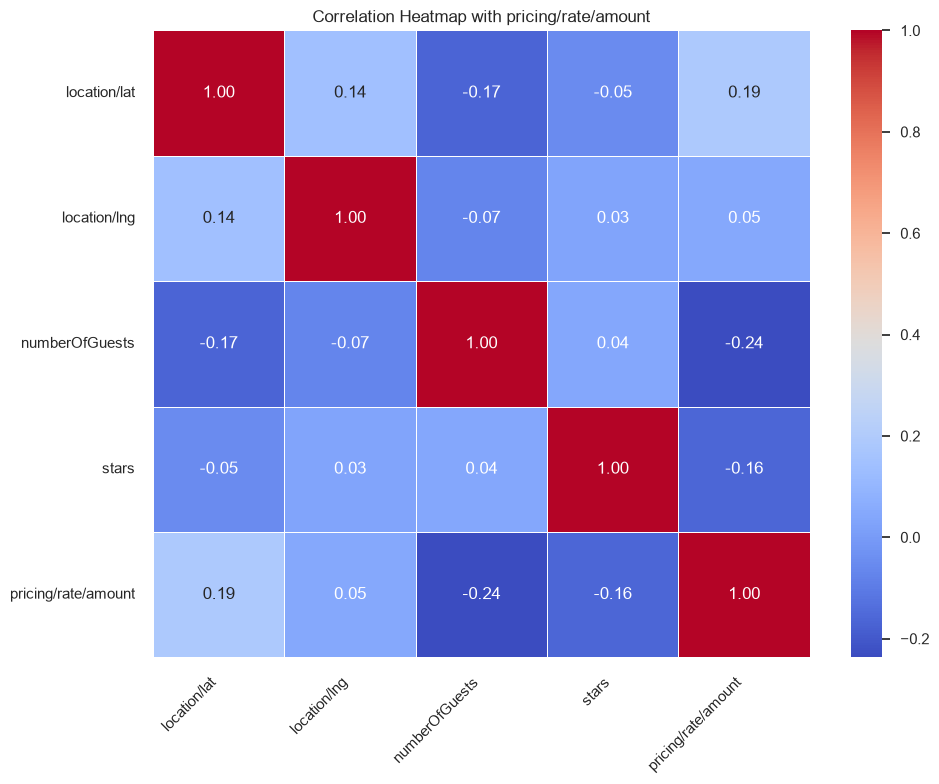


Creating price distribution plot (0 - 1000 INR)...


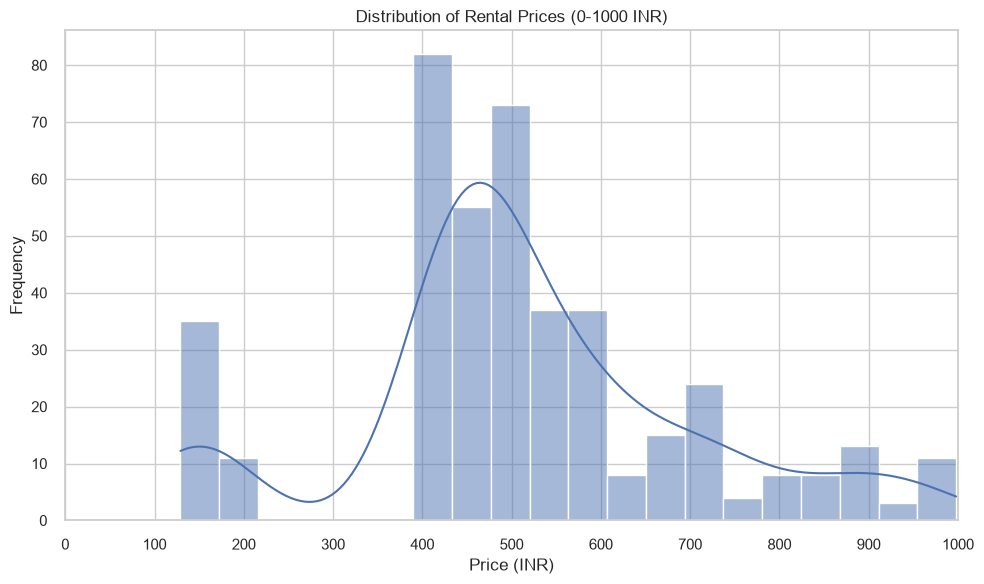


Creating rating distribution plot...


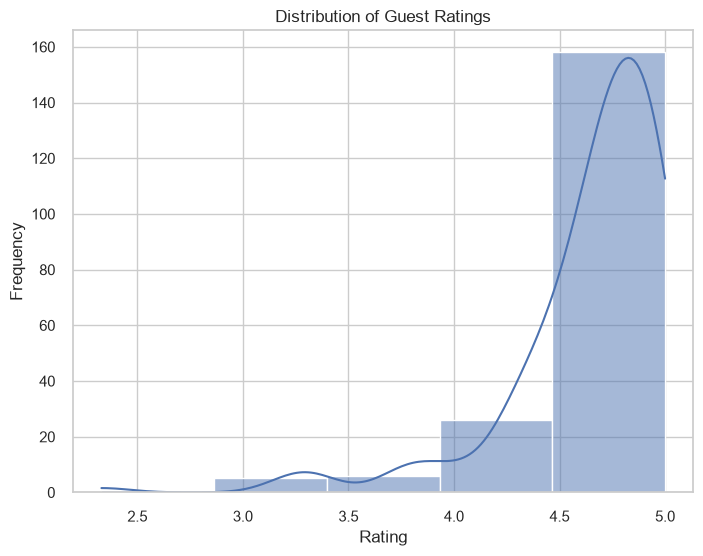


Creating superhost comparison plot...


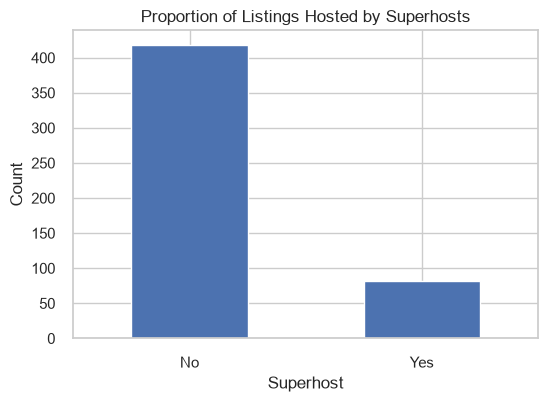


Creating price vs rating scatter plot...


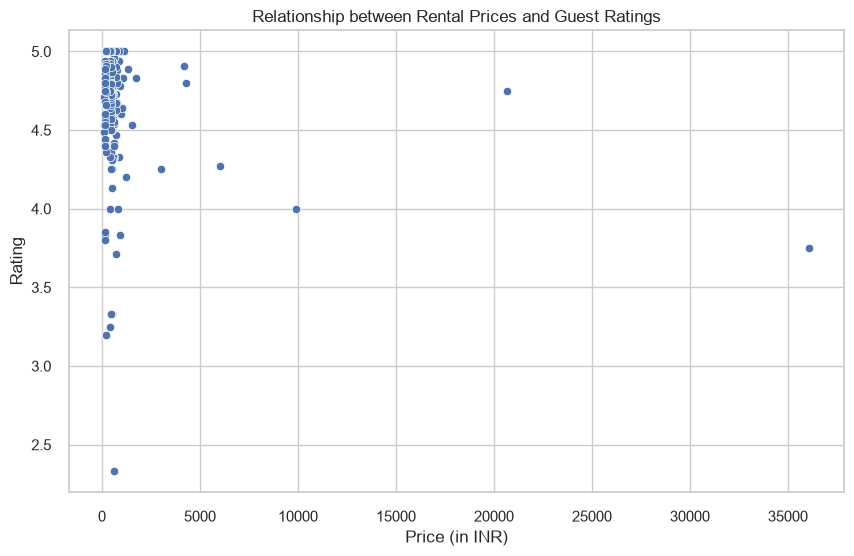


Creating room type distribution plot...


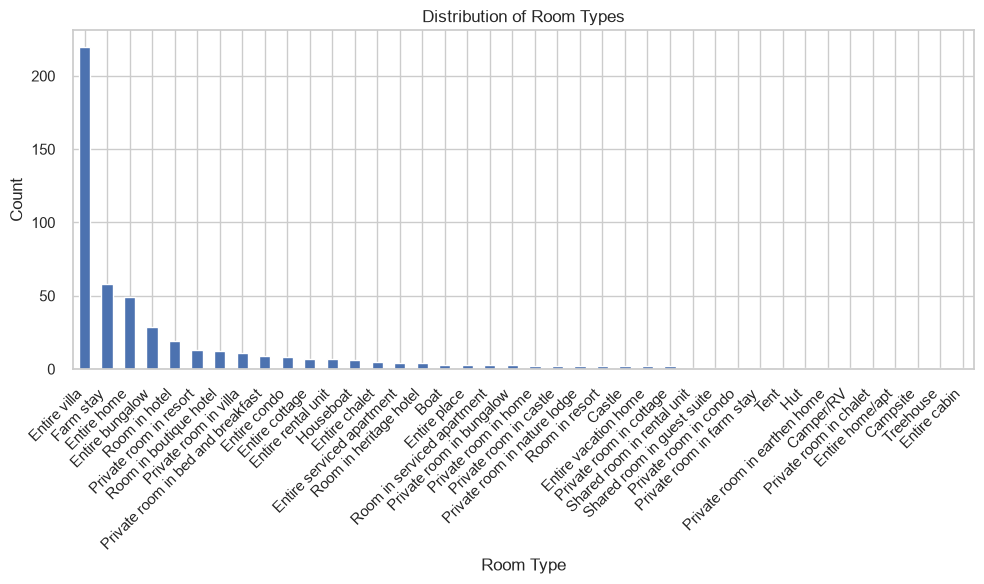


Creating median price by room type plot...


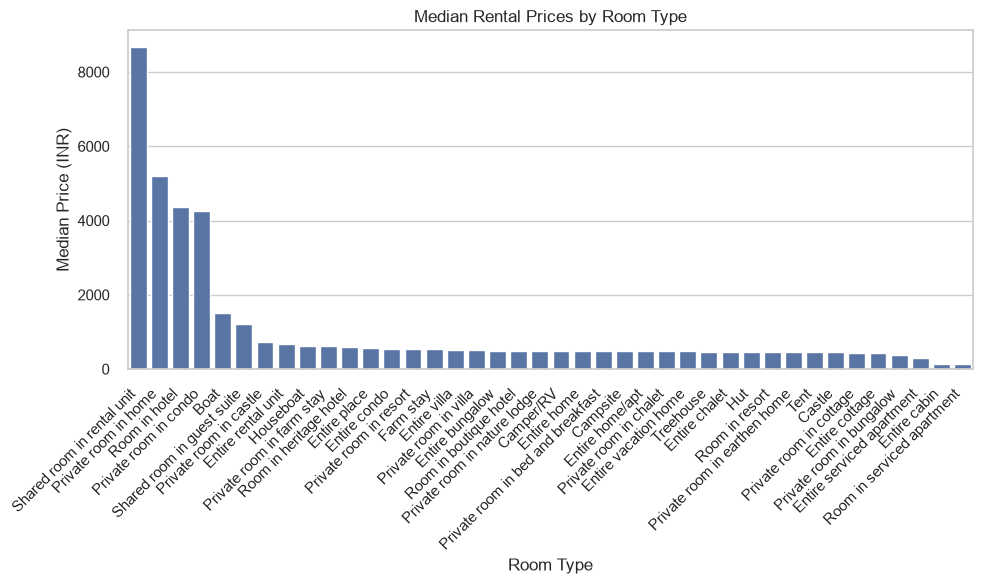

Skipping map because latitude/longitude columns or Plotly were not available.

Creating accommodation capacity plot...


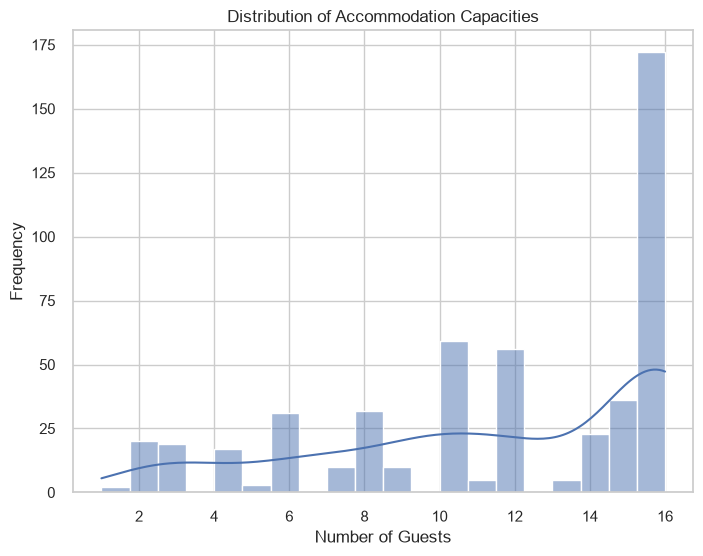


Creating capacity vs price scatter plot...


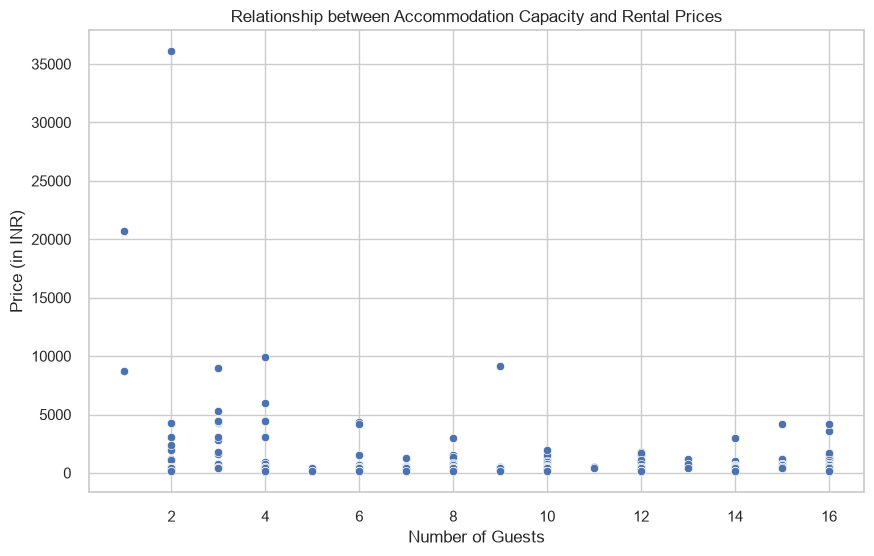


Creating superhost vs non-superhost comparison plot...


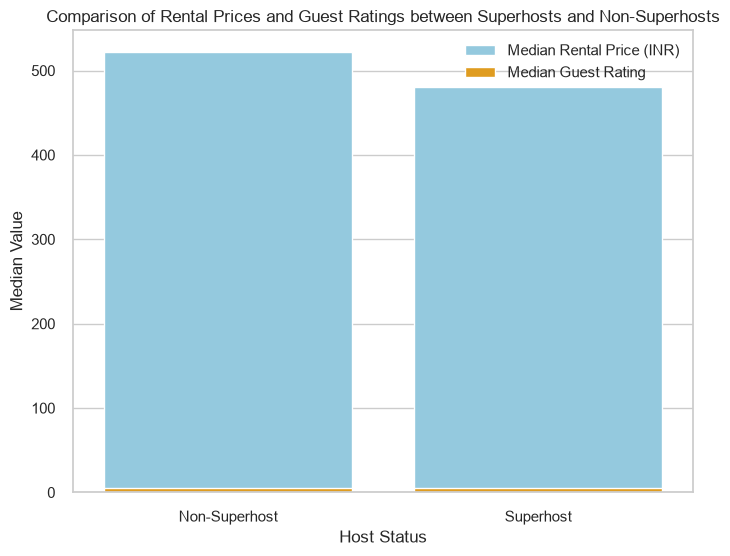

In [211]:
if df is not None:
    data = df.copy()

    def find_column(candidates, columns):
        normalized_columns = {
            str(col).strip().lower().replace(' ', '').replace('_', ''): col
            for col in columns
        }
        for candidate in candidates:
            key = str(candidate).strip().lower().replace(' ', '').replace('_', '')
            if key in normalized_columns:
                return normalized_columns[key]
        return None

    print('Starting column detection for EDA...')
    price_col = find_column(['pricing/rate/amount', 'price', 'rate_amount'], data.columns)
    rating_col = find_column(['stars', 'review_scores_rating', 'rating'], data.columns)
    superhost_col = find_column(['isHostedBySuperhost', 'host_is_superhost', 'superhost'], data.columns)
    room_col = find_column(['roomType', 'room_type', 'roomtype'], data.columns)
    guests_col = find_column(['numberOfGuests', 'accommodates', 'guests'], data.columns)
    lat_col = find_column(['location/lat', 'latitude', 'lat'], data.columns)
    lon_col = find_column(['location/lng', 'longitude', 'lng'], data.columns)
    name_col = find_column(['name', 'listing_name'], data.columns)

    print('\nColumn detection summary:')
    print(f"- Price column: {price_col if price_col else 'Not found'}")
    print(f"- Rating column: {rating_col if rating_col else 'Not found'}")
    print(f"- Superhost column: {superhost_col if superhost_col else 'Not found'}")
    print(f"- Room type column: {room_col if room_col else 'Not found'}")
    print(f"- Guest capacity column: {guests_col if guests_col else 'Not found'}")
    print(f"- Latitude column: {lat_col if lat_col else 'Not found'}")
    print(f"- Longitude column: {lon_col if lon_col else 'Not found'}")
    print(f"- Listing name column: {name_col if name_col else 'Not found'}")
    print('\nAvailable columns in the dataset:')
    print(', '.join(data.columns.tolist()))

    # Pearson correlation with the target variable
    if price_col is not None:
        print('\nCalculating Pearson correlation with the target variable...')
        numeric_data = data.select_dtypes(include=['number']).copy()
        if price_col in numeric_data.columns:
            numeric_data = numeric_data.drop(columns=[price_col], errors='ignore')
        if not numeric_data.empty:
            corr = numeric_data.corrwith(data[price_col]).sort_values(ascending=False)
            print('\nPearson correlation with price:')
            print(corr)

            from IPython.display import display
            corr_matrix = pd.concat([numeric_data, data[[price_col]]], axis=1).corr()
            print('\nCorrelation heatmap table:')
            display(corr_matrix.round(2))

            plt.figure(figsize=(10, 8))
            sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
            plt.title(f'Correlation Heatmap with {price_col}')
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()
        else:
            print('No numeric columns available for Pearson correlation.')
    else:
        print('Skipping Pearson correlation because no suitable price column was found.')


    import numpy as np
    # Distribution of rental prices
    if price_col is not None:
        print('\nCreating price distribution plot (0 - 1000 INR)...')

        prices = data[price_col].dropna()

        # Keep only prices up to 1000
        prices = prices[prices <= 1000]

        plt.figure(figsize=(10,6))

        sns.histplot(prices, bins=20, kde=True)

        plt.title('Distribution of Rental Prices (0-1000 INR)')
        plt.xlabel('Price (INR)')
        plt.ylabel('Frequency')

        plt.xlim(0, 1000)
        plt.xticks(np.arange(0, 1001, 100))

        plt.tight_layout()
        plt.show()
    else:
        print('Skipping price distribution because no matching price column was found.')

    # Distribution of guest ratings
    if rating_col is not None:
        print('\nCreating rating distribution plot...')
        plt.figure(figsize=(8, 6))
        sns.histplot(data[rating_col].dropna(), bins=5, kde=True)
        plt.title('Distribution of Guest Ratings')
        plt.xlabel('Rating')
        plt.ylabel('Frequency')
        plt.show()
    else:
        print('Skipping rating distribution because no matching rating column was found.')

    # Proportion of listings hosted by superhosts
    if superhost_col is not None:
        print('\nCreating superhost comparison plot...')
        plt.figure(figsize=(6, 4))
        data[superhost_col].value_counts().plot(kind='bar')
        plt.title('Proportion of Listings Hosted by Superhosts')
        plt.xlabel('Superhost')
        plt.ylabel('Count')
        plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
        plt.show()
    else:
        print('Skipping superhost plot because no matching superhost column was found.')

    # Relationship between rental prices and guest ratings
    if price_col is not None and rating_col is not None:
        print('\nCreating price vs rating scatter plot...')
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=price_col, y=rating_col, data=data)
        plt.title('Relationship between Rental Prices and Guest Ratings')
        plt.xlabel('Price (in INR)')
        plt.ylabel('Rating')
        plt.show()
    else:
        print('Skipping price vs rating plot because the required columns were not found.')

    # Distribution of room types
    if room_col is not None:
        print('\nCreating room type distribution plot...')
        plt.figure(figsize=(10, 6))
        room_type_counts = data[room_col].value_counts()
        room_type_counts.plot(kind='bar')
        plt.title('Distribution of Room Types')
        plt.xlabel('Room Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print('Skipping room type plot because no matching room type column was found.')

    # Median rental prices by room type
    if room_col is not None and price_col is not None:
        print('\nCreating median price by room type plot...')
        room_type_median_prices = data.groupby(room_col)[price_col].median().reset_index()
        room_type_median_prices = room_type_median_prices.sort_values(price_col, ascending=False)

        if px is not None:
            fig = px.bar(
                room_type_median_prices,
                x=room_col,
                y=price_col,
                title='Median Rental Prices by Room Type',
                labels={room_col: 'Room Type', price_col: 'Median Price (INR)'}
            )
            fig.show()
        else:
            plt.figure(figsize=(10, 6))
            sns.barplot(data=room_type_median_prices, x=room_col, y=price_col)
            plt.title('Median Rental Prices by Room Type')
            plt.xlabel('Room Type')
            plt.ylabel('Median Price (INR)')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
    else:
        print('Skipping median price by room type plot because the required columns were not found.')

    # Geographical hotspots for listings
    if lat_col is not None and lon_col is not None and px is not None:
        print('\nCreating listing map...')
        fig = px.scatter_mapbox(
            data,
            lat=lat_col,
            lon=lon_col,
            color_discrete_sequence=['blue'],
            zoom=3.5,
            title='Distribution of Airbnb Listings in India',
            height=600,
            hover_name=name_col if name_col else None
        )
        fig.update_layout(mapbox_style='open-street-map')
        fig.show()
    else:
        print('Skipping map because latitude/longitude columns or Plotly were not available.')

    # Distribution of accommodation capacities
    if guests_col is not None:
        print('\nCreating accommodation capacity plot...')
        plt.figure(figsize=(8, 6))
        sns.histplot(data[guests_col].dropna(), bins=20, kde=True)
        plt.title('Distribution of Accommodation Capacities')
        plt.xlabel('Number of Guests')
        plt.ylabel('Frequency')
        plt.show()
    else:
        print('Skipping capacity plot because no matching guest capacity column was found.')

    # Relationship between accommodation capacity and rental prices
    if guests_col is not None and price_col is not None:
        print('\nCreating capacity vs price scatter plot...')
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=guests_col, y=price_col, data=data)
        plt.title('Relationship between Accommodation Capacity and Rental Prices')
        plt.xlabel('Number of Guests')
        plt.ylabel('Price (in INR)')
        plt.show()
    else:
        print('Skipping capacity vs price plot because the required columns were not found.')

    # Comparison between superhosts and non-superhosts
    if superhost_col is not None and price_col is not None and rating_col is not None:
        print('\nCreating superhost vs non-superhost comparison plot...')
        host_stats = data.groupby(superhost_col).agg({price_col: 'median', rating_col: 'median'}).reset_index()
        host_stats[superhost_col] = host_stats[superhost_col].map({True: 'Superhost', False: 'Non-Superhost'})

        plt.figure(figsize=(8, 6))
        sns.barplot(x=superhost_col, y=price_col, data=host_stats, color='skyblue', label='Median Rental Price (INR)')
        sns.barplot(x=superhost_col, y=rating_col, data=host_stats, color='orange', label='Median Guest Rating')
        plt.title('Comparison of Rental Prices and Guest Ratings between Superhosts and Non-Superhosts')
        plt.xlabel('Host Status')
        plt.ylabel('Median Value')
        plt.legend()
        plt.xticks(rotation=0)
        plt.show()
    else:
        print('Skipping superhost comparison plot because the required columns were not found.')
else:
    print('Visualization skipped because the dataset is not available yet.')

## Step 5: Model Selection & Training

A simple regression model can be trained after preparing the features.

Possible models:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor


In [212]:
if df is not None and train_test_split is not None:
    model_df = df.copy()

    target_col = next((col for col in ['pricing/rate/amount', 'price', 'rate_amount'] if col in model_df.columns), None)
    if target_col is None:
        print('No suitable target column found for training. Please update the dataset columns.')
    else:
        feature_cols = [col for col in model_df.columns if col != target_col]
        feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(model_df[col]) or pd.api.types.is_object_dtype(model_df[col])]

        X = model_df[feature_cols].copy()
        y = model_df[target_col]

        for col in X.columns:
            if pd.api.types.is_bool_dtype(X[col]):
                X[col] = X[col].astype(object)
            elif pd.api.types.is_integer_dtype(X[col]) and X[col].isnull().any():
                X[col] = X[col].astype(float)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
        categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

        print('Preparing the preprocessing pipeline...')
        print('Step 1: Numerical columns are filled with the median value.')
        print('Step 2: Categorical columns are filled with the most frequent value.')
        print('Step 3: Categorical values are converted into numeric form using one-hot encoding.')
        print('This pipeline helps the model learn from both numeric and categorical data.')

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', SimpleImputer(strategy='median'), numeric_features),
                ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
            ]
        )

        model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        print('Model trained successfully.')
        print('MAE:', round(mae, 2))
        print('RMSE:', round(rmse, 2))
        print('R2 Score:', round(r2, 2))
else:
    print('Training skipped because the dataset or required scikit-learn modules are not available.')

Preparing the preprocessing pipeline...
Step 1: Numerical columns are filled with the median value.
Step 2: Categorical columns are filled with the most frequent value.
Step 3: Categorical values are converted into numeric form using one-hot encoding.
This pipeline helps the model learn from both numeric and categorical data.
Model trained successfully.
MAE: 766.02
RMSE: 1293.31
R2 Score: 0.13


## Step 6: Evaluation & Hyperparameter Tuning

After training the model, evaluate its performance and improve it through tuning.

Metrics to use:
- MAE
- RMSE
- R2 Score


In [213]:
if df is not None:
    model_df = df.copy()
    target_col = next((col for col in ['pricing/rate/amount', 'price', 'rate_amount'] if col in model_df.columns), None)

    if target_col is not None:
        feature_cols = [col for col in model_df.columns if col != target_col]
        feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(model_df[col]) or pd.api.types.is_object_dtype(model_df[col])]

        X = model_df[feature_cols].copy()
        y = model_df[target_col]

        for col in X.columns:
            if pd.api.types.is_bool_dtype(X[col]):
                X[col] = X[col].astype(object)
            elif pd.api.types.is_integer_dtype(X[col]) and X[col].isnull().any():
                X[col] = X[col].astype(float)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
        categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', SimpleImputer(strategy='median'), numeric_features),
                ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
            ]
        )

        models = {
            'Linear Regression': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())]),
            'Random Forest': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))]),
            'Gradient Boosting': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(random_state=42))])
        }

        results = []
        for name, pipe in models.items():
            print(f'\nTraining {name}...')
            pipe.fit(X_train, y_train)
            preds = pipe.predict(X_test)
            mae = mean_absolute_error(y_test, preds)
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            r2 = r2_score(y_test, preds)
            results.append((name, mae, rmse, r2))
            print(f'{name} -> MAE: {round(mae, 2)}, RMSE: {round(rmse, 2)}, R2: {round(r2, 2)}')

        results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2 Score'])
        results_df = results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
        print('\nComparison of model results:')
        print(results_df)

        best_model = results_df.loc[0, 'Model']
        best_r2 = results_df.loc[0, 'R2 Score']
        print(f'\nBest model based on R2 Score: {best_model}')
        print(f'R2 Score: {round(best_r2, 2)}')

        if best_model == 'Linear Regression':
            print('Conclusion: Linear Regression performs best for this dataset based on the R2 score.')
        elif best_model == 'Random Forest':
            print('Conclusion: Random Forest performs best because it captures non-linear patterns better and gives the highest R2 score.')
        elif best_model == 'Gradient Boosting':
            print('Conclusion: Gradient Boosting performs best because it gives the strongest predictive performance on this dataset.')
    else:
        print('No suitable target column found for model comparison.')
else:
    print('Model comparison skipped because the dataset is not available.')


Training Linear Regression...
Linear Regression -> MAE: 766.02, RMSE: 1293.31, R2: 0.13

Training Random Forest...
Random Forest -> MAE: 632.15, RMSE: 1310.38, R2: 0.1

Training Gradient Boosting...
Gradient Boosting -> MAE: 540.56, RMSE: 1221.94, R2: 0.22

Comparison of model results:
               Model         MAE         RMSE  R2 Score
0  Gradient Boosting  540.561991  1221.939418  0.221354
1  Linear Regression  766.021364  1293.305330  0.127746
2      Random Forest  632.150643  1310.383465  0.104558

Best model based on R2 Score: Gradient Boosting
R2 Score: 0.22
Conclusion: Gradient Boosting performs best because it gives the strongest predictive performance on this dataset.


## Step 7: Deployment & Monitoring

Once the model is trained and evaluated, it can be saved and deployed in a future application.

Possible next steps:
- Save the trained model
- Create a simple web app or API
- Monitor prediction quality over time


In [214]:
from joblib import dump

if df is not None:
    model_df = df.copy()
    target_col = next((col for col in ['pricing/rate/amount', 'price', 'rate_amount'] if col in model_df.columns), None)

    if target_col is not None:
        feature_cols = [col for col in model_df.columns if col != target_col]
        feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(model_df[col]) or pd.api.types.is_object_dtype(model_df[col])]

        X = model_df[feature_cols].copy()
        y = model_df[target_col]

        for col in X.columns:
            if pd.api.types.is_bool_dtype(X[col]):
                X[col] = X[col].astype(object)
            elif pd.api.types.is_integer_dtype(X[col]) and X[col].isnull().any():
                X[col] = X[col].astype(float)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
        categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', SimpleImputer(strategy='median'), numeric_features),
                ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
            ]
        )

        final_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])
        final_model.fit(X_train, y_train)

        output_path = Path('model_airbnb_price_predictor.joblib')
        dump(final_model, output_path)
        print(f'Model saved successfully at {output_path}')
    else:
        print('No suitable target column found for saving the model.')
else:
    print('Model saving skipped because the dataset is not available.')

Model saved successfully at model_airbnb_price_predictor.joblib


## Step 8: Test the Model on Unknown Data Points

This section creates a new sample listing using the dataset's most typical feature values, then predicts a rental price for that unseen listing.

In [215]:
if df is not None and train_test_split is not None:
    model_df = df.copy()
    target_col = next((col for col in ['pricing/rate/amount', 'price', 'rate_amount'] if col in model_df.columns), None)

    if target_col is not None:
        feature_cols = [col for col in model_df.columns if col != target_col]
        feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(model_df[col]) or pd.api.types.is_object_dtype(model_df[col])]

        X = model_df[feature_cols].copy()
        y = model_df[target_col]

        for col in X.columns:
            if pd.api.types.is_bool_dtype(X[col]):
                X[col] = X[col].astype(object)
            elif pd.api.types.is_integer_dtype(X[col]) and X[col].isnull().any():
                X[col] = X[col].astype(float)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
        categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', SimpleImputer(strategy='median'), numeric_features),
                ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
            ]
        )

        final_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])
        final_model.fit(X_train, y_train)

        sample_listing = {}
        for col in X.columns:
            if col in numeric_features:
                sample_listing[col] = float(X[col].median(skipna=True) if X[col].notna().any() else 0)
            else:
                modes = X[col].mode(dropna=True)
                sample_listing[col] = modes.iloc[0] if not modes.empty else 'Unknown'

        sample_df = pd.DataFrame([sample_listing])
        predicted_price = final_model.predict(sample_df)

        print('Sample listing used for prediction:')
        print(sample_listing)
        print('\nPredicted rental price for the sample listing (INR):', round(predicted_price[0], 2))

        sample_listings_1 = [
            {
                "address": "Bangalore, Karnataka, India",
                "isHostedBySuperhost": False,
                "location/lat": 12.9716,
                "location/lng": 77.5946,
                "name": "Budget Stay",
                "numberOfGuests": 2,
                "roomType": "Private room",
                "stars": 3.8
            },
            {
                "address": "Goa, India",
                "isHostedBySuperhost": True,
                "location/lat": 15.4909,
                "location/lng": 73.8278,
                "name": "Luxury Beach Villa",
                "numberOfGuests": 10,
                "roomType": "Entire villa",
                "stars": 4.9
            },
            {
                "address": "Mumbai, India",
                "isHostedBySuperhost": True,
                "location/lat": 19.0760,
                "location/lng": 72.8777,
                "name": "Sea View Apartment",
                "numberOfGuests": 4,
                "roomType": "Entire apartment",
                "stars": 4.6
            }
        ]

        sample_df_1 = pd.DataFrame(sample_listings_1)

        predictions = final_model.predict(sample_df_1)

        sample_df_1["Predicted Price (INR)"] = predictions.round(2)

        # print(sample_df_1)
        print("=" * 80)
        print("AIRBNB RENTAL PRICE PREDICTIONS")
        print("=" * 80)

        for i in range(len(sample_df_1)):
            print(f"\nSample Listing {i + 1}")
            print("-" * 80)

            print(f"Address            : {sample_df_1.iloc[i]['address']}")
            print(f"Property Name      : {sample_df_1.iloc[i]['name']}")
            print(f"Room Type          : {sample_df_1.iloc[i]['roomType']}")
            print(f"Guests             : {sample_df_1.iloc[i]['numberOfGuests']}")
            print(f"Rating             : {sample_df_1.iloc[i]['stars']}")
            print(f"Superhost          : {sample_df_1.iloc[i]['isHostedBySuperhost']}")
            print(f"Latitude           : {sample_df_1.iloc[i]['location/lat']}")
            print(f"Longitude          : {sample_df_1.iloc[i]['location/lng']}")

            print(f"\n Predicted Price : ₹{sample_df_1.iloc[i]['Predicted Price (INR)']:,.2f} per night")

        print("\n" + "=" * 80)


    else:
        print('No suitable target column found for unknown data testing.')
else:
    print('Unknown data testing skipped because the dataset or required modules are not available.')

Sample listing used for prediction:
{'isHostedBySuperhost': False, 'location/lat': 17.92089, 'location/lng': 73.80414, 'numberOfGuests': 12.0, 'stars': 4.75}

Predicted rental price for the sample listing (INR): 552.64
AIRBNB RENTAL PRICE PREDICTIONS

Sample Listing 1
--------------------------------------------------------------------------------
Address            : Bangalore, Karnataka, India
Property Name      : Budget Stay
Room Type          : Private room
Guests             : 2
Rating             : 3.8
Superhost          : False
Latitude           : 12.9716
Longitude          : 77.5946

 Predicted Price : ₹6,825.13 per night

Sample Listing 2
--------------------------------------------------------------------------------
Address            : Goa, India
Property Name      : Luxury Beach Villa
Room Type          : Entire villa
Guests             : 10
Rating             : 4.9
Superhost          : True
Latitude           : 15.4909
Longitude          : 73.8278

 Predicted Price : ₹39

## Project Summary and Key Outcomes

- **Project goal:** Explore Indian Airbnb rental pricing and build a regression model to predict listing price.
- **Data preparation:** Cleaned duplicates, identified key columns, handled missing values, and prepared numeric/categorical features for modeling.
- **Exploratory findings:** Visualized price distribution, guest rating distribution, superhost proportions, room type breakdown, price vs rating relationships, and capacity vs price.
- **Modeling outcome:** Trained Linear Regression, Random Forest, and Gradient Boosting models, then compared them using MAE, RMSE, and R2 score.
- **Deployment readiness:** Saved the final model pipeline to `model_airbnb_price_predictor.joblib` for future use.

### Recommended features for Indian Airbnb price prediction
- `room_type` or similar listing type
- `accommodates`, `bedrooms`, `bathrooms`, and guest capacity
- `review_scores_rating` or listing quality indicators
- `host_is_superhost` or host reputation features
- Location-related fields such as `city`, `latitude`, `longitude`, or neighborhood
- Amenity and availability features where available

### Why these features make sense
- Capacity and room type directly affect how much guests are willing to pay.
- Guest ratings and superhost status reflect listing quality and trust.
- Location determines demand, local price levels, and travel convenience.
- Structured categorical features can be encoded and combined with numeric features in a regression pipeline.

### Next steps
1. Add more location-based and amenity features.
2. Tune the best model further using hyperparameter search.
3. Validate predictions on a larger hold-out dataset or real unseen listings.